In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sdv.metadata import Metadata
from sdv.single_table import TVAESynthesizer

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import RandomOverSampler

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# 1. Load the original dataset
data = pd.read_csv('labeled_ml_input_70.csv')

data.columns = [
    'Age', 'Gender', 'District', 'Education_Level', 'Qualification',
    'Years_Experience', 'Languages_Spoken', 'Care_Category',
    'Care_Service_Type', 'Preferred_Time', 'Expected_Salary', 'Match_Decision'
]

def clean_salary(val):
    val = str(val).replace(',', '').strip()
    if '-' in val:
        try:
            parts = val.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return 0.0
    try:
        return float(val)
    except:
        return 0.0

data['Expected_Salary'] = data['Expected_Salary'].apply(clean_salary)

print("Data loaded and preprocessed.")
print(data.head())

Data loaded and preprocessed.
   Age  Gender    District         Education_Level  \
0   26  Female     Colombo  Secondary/Short Course   
1   52    Male      Jaffna                  Degree   
2   24  Female  Kurunegala                 Diploma   
3   47  Female     Colombo                  Degree   
4   27    Male    Puttalam                  Degree   

                                       Qualification  Years_Experience  \
0  NVQ Level 3,NVQ Level 4,First Aid Certificate,...               1.0   
1                                        NVQ Level 3               5.0   
2                                        NVQ Level 3               0.0   
3                                        NVQ Level 3               1.0   
4                                        NVQ Level 3               0.0   

        Languages_Spoken Care_Category Care_Service_Type Preferred_Time  \
0        Sinhala,English  Elderly care               NaN            NaN   
1          English,Tamil  Elderly care        All-

In [3]:
# 2. Dataset validation and cleaning
print("\nDataset Validation:")
print("Total records: {}".format(len(data)))
print("Total features: {}".format(len(data.columns) - 1))

missing_count = data.isnull().sum().sum()
if missing_count > 0:
    print("Missing values found: {}".format(missing_count))
else:
    print("No missing values detected")

for col in data.columns:
    if data[col].isnull().sum() > 0:
        if data[col].dtype == 'object':
            data[col] = data[col].fillna('Unknown')
        else:
            data[col] = data[col].fillna(data[col].median())

duplicate_count = data.duplicated().sum()
if duplicate_count > 0:
    print("Duplicate records found: {}".format(duplicate_count))
    data = data.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed")
else:
    print("No duplicate records found")

print("\nTarget variable distribution:")
print(data['Match_Decision'].value_counts())

print("Dataset validation complete.")


Dataset Validation:
Total records: 70
Total features: 11
Missing values found: 7
No duplicate records found

Target variable distribution:
Match_Decision
Accepted    48
Rejected    22
Name: count, dtype: int64
Dataset validation complete.


In [4]:
# 3. Split BEFORE boosting
target_col = "Match_Decision"

X = data.drop(target_col, axis=1).copy()
y = data[target_col].copy()

X_train_real, X_test_real, y_train_real, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_real = pd.concat(
    [X_train_real.reset_index(drop=True), y_train_real.reset_index(drop=True)],
    axis=1
)

test_real = pd.concat(
    [X_test_real.reset_index(drop=True), y_test.reset_index(drop=True)],
    axis=1
)

print("Data split into training and testing sets.")
print("Training samples (real only):", len(train_real))
print("Testing samples (untouched real data):", len(test_real))

print("\nTraining target distribution before boosting:")
print(train_real['Match_Decision'].value_counts())

print("\nTesting target distribution:")
print(test_real['Match_Decision'].value_counts())

Data split into training and testing sets.
Training samples (real only): 56
Testing samples (untouched real data): 14

Training target distribution before boosting:
Match_Decision
Accepted    38
Rejected    18
Name: count, dtype: int64

Testing target distribution:
Match_Decision
Accepted    10
Rejected     4
Name: count, dtype: int64


In [5]:
# 4. Setup metadata using training data only
metadata = Metadata.detect_from_dataframe(
    data=train_real,
    table_name='elderly_train_data'
)

multi_value_cols = ['Languages_Spoken', 'Qualification', 'Care_Category']
for col in multi_value_cols:
    metadata.update_column(
        table_name='elderly_train_data',
        column_name=col,
        sdtype='categorical'
    )

print("Metadata configured for training data.")

Metadata configured for training data.


In [6]:
# 5. Train TVAE only on training data
print("Initializing TVAE for training-set boosting...")
tvae = TVAESynthesizer(metadata=metadata, epochs=500)
tvae.fit(train_real)

print("TVAE training complete.")

Initializing TVAE for training-set boosting...


/opt/anaconda3/lib/python3.13/site-packages/sdv/single_table/base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



TVAE training complete.


In [7]:
# 6. Generate synthetic training data only
TARGET_TRAIN_TOTAL = 1200

synthetic_rows_needed = max(0, TARGET_TRAIN_TOTAL - len(train_real))
synthetic_data = tvae.sample(num_rows=synthetic_rows_needed)

boosted_train = pd.concat([train_real, synthetic_data], ignore_index=True)

print("Training data boosted.")
print("Original training rows:", len(train_real))
print("Synthetic training rows:", len(synthetic_data))
print("Total boosted training rows:", len(boosted_train))

print("\nBoosted training target distribution BEFORE final balancing:")
print(boosted_train['Match_Decision'].value_counts())

boosted_train.to_csv("Boosted_dataset.csv", index=False)
print("Boosted training dataset saved.")

Training data boosted.
Original training rows: 56
Synthetic training rows: 1144
Total boosted training rows: 1200

Boosted training target distribution BEFORE final balancing:
Match_Decision
Accepted    965
Rejected    235
Name: count, dtype: int64
Boosted training dataset saved.


In [8]:
# 7. Separate boosted training set and untouched test set
X_train = boosted_train.drop(target_col, axis=1).copy()
y_train = boosted_train[target_col].copy()

X_test = test_real.drop(target_col, axis=1).copy()
y_test = test_real[target_col].copy()

print("Boosted training features and real test features prepared.")

Boosted training features and real test features prepared.


In [9]:
# 8. Encode categorical columns
categorical_cols = [
    'Gender', 'District', 'Education_Level', 'Qualification',
    'Languages_Spoken', 'Care_Category', 'Care_Service_Type', 'Preferred_Time'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = X_train[col].fillna("None").astype(str)
    X_test[col] = X_test[col].fillna("None").astype(str)

    le.fit(X_train[col])

    if "None" not in le.classes_:
        le.classes_ = np.append(le.classes_, "None")

    X_train[col] = X_train[col].apply(lambda v: v if v in le.classes_ else "None")
    X_train[col] = le.transform(X_train[col])

    X_test[col] = X_test[col].apply(lambda v: v if v in le.classes_ else "None")
    X_test[col] = le.transform(X_test[col])

    encoders[col] = le

print("Encoding completed.")

Encoding completed.


In [10]:
# 9. Scale numeric features
numeric_features = ['Age', 'Years_Experience', 'Expected_Salary']

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Scaling completed.")

Scaling completed.


In [11]:
# 10. Final balancing after TVAE boosting
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

print("Final balancing completed.")

print("\nTraining target distribution AFTER final balancing:")
print(pd.Series(y_train_balanced).value_counts())

Final balancing completed.

Training target distribution AFTER final balancing:
Match_Decision
Accepted    965
Rejected    965
Name: count, dtype: int64


In [12]:
# 11. Train Logistic Regression model
print("Training Logistic Regression model...")

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_balanced, y_train_balanced)

print("Training complete.")

Training Logistic Regression model...
Training complete.


In [13]:
# 12. Evaluate model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 92.86%

Classification Report:
              precision    recall  f1-score   support

    Accepted       0.91      1.00      0.95        10
    Rejected       1.00      0.75      0.86         4

    accuracy                           0.93        14
   macro avg       0.95      0.88      0.90        14
weighted avg       0.94      0.93      0.93        14



Generating learning curve...


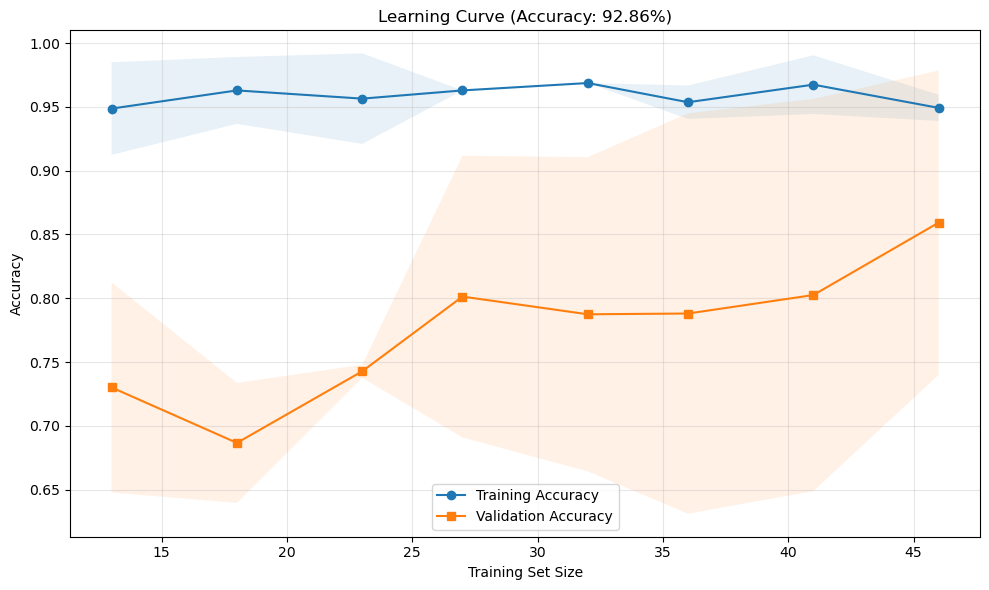

Learning curve saved to: ml_outputs/learning_curve_logreg_acc_92.86.png


In [20]:
# 13. Learning curve
print("Generating learning curve...")

X_all = data.drop(target_col, axis=1).copy()
y_all = data[target_col].copy()

for col in categorical_cols:
    le = encoders[col]
    X_all[col] = X_all[col].fillna("None").astype(str)
    X_all[col] = X_all[col].apply(lambda v: v if v in le.classes_ else "None")
    X_all[col] = le.transform(X_all[col])

X_all[numeric_features] = scaler.transform(X_all[numeric_features])

OUTPUT_DIR = "ml_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_all,
    y_all,
    cv=3,
    n_jobs=-1,
    train_sizes=np.linspace(0.3, 1.0, 8),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

acc_percent = accuracy * 100

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Accuracy", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)

plt.plot(train_sizes, test_mean, label="Validation Accuracy", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve (Accuracy: {acc_percent:.2f}%)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()

lc_path = os.path.join(OUTPUT_DIR, f"learning_curve_logreg_acc_{acc_percent:.2f}.png")
plt.savefig(lc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Learning curve saved to:", lc_path)

Generating confusion matrix...


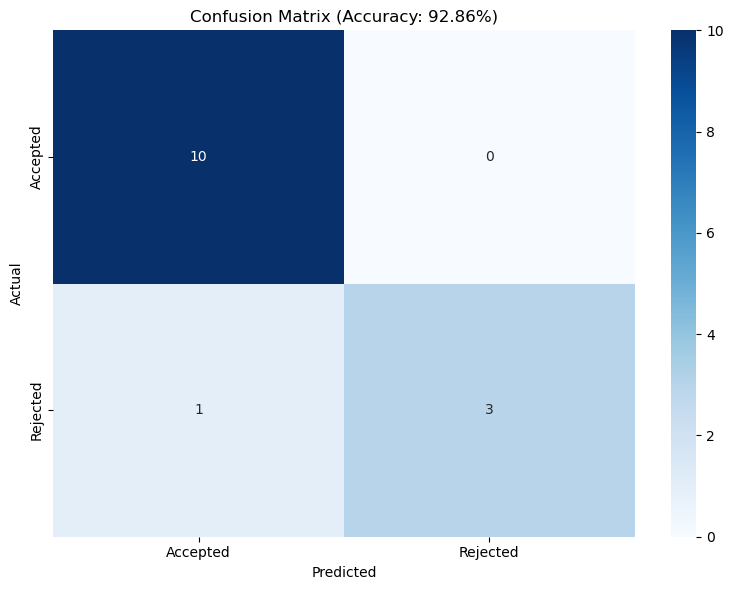

Confusion matrix saved to: ml_outputs/confusion_matrix_logreg_acc_92.86.png


In [15]:
# 14. Confusion matrix
print("Generating confusion matrix...")

cm = confusion_matrix(y_test, y_pred, labels=["Accepted", "Rejected"])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Accepted", "Rejected"],
    yticklabels=["Accepted", "Rejected"]
)

plt.title(f"Confusion Matrix (Accuracy: {acc_percent:.2f}%)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_logreg_acc_{acc_percent:.2f}.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", cm_path)

Generating coefficient importance visualization...


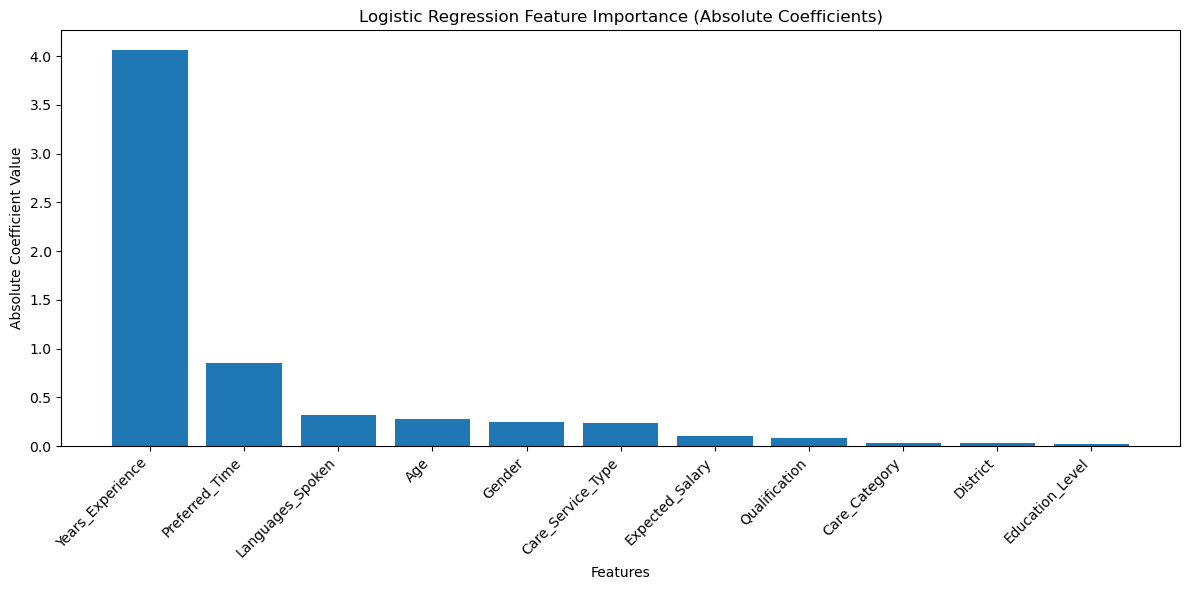

Coefficient importance saved to: ml_outputs/coef_importance_logreg_acc_92.86.png


In [16]:
# 15. Logistic Regression coefficient importance
print("Generating coefficient importance visualization...")

coef_values = np.abs(model.coef_[0])
feature_names = X.columns
indices = np.argsort(coef_values)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Logistic Regression Feature Importance (Absolute Coefficients)")
plt.bar(range(len(coef_values)), coef_values[indices], align="center")
plt.xticks(
    range(len(coef_values)),
    [feature_names[i] for i in indices],
    rotation=45,
    ha='right'
)
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient Value')
plt.tight_layout()

coef_path = os.path.join(OUTPUT_DIR, f"coef_importance_logreg_acc_{acc_percent:.2f}.png")
plt.savefig(coef_path, dpi=300, bbox_inches="tight")
plt.show()

print("Coefficient importance saved to:", coef_path)

In [17]:
# 16. Save final model for backend
joblib.dump({
    'model': model,
    'encoders': encoders,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'model_type': 'LogisticRegression'
}, 'elderlyln_matcher_final.pkl')

print("Final Logistic Regression model saved for backend.")

Final Logistic Regression model saved for backend.
